# Multilayer Perceptron (MLP)

## Overview

The **Multilayer Perceptron** is a fully-connected feedforward neural network — the foundational architecture of modern deep learning. Unlike the single-layer Perceptron, the MLP can learn **non-linear decision boundaries** by stacking layers of neurons with non-linear activation functions.

The key insight is that hidden layers act as learned feature transformers, allowing the network to represent complex relationships that no linear model can capture.

---

## Architecture

This implementation uses a **two-layer architecture**:

$$\text{Input} \xrightarrow{W^{(1)}, b^{(1)}} \text{Hidden Layer} \xrightarrow{\sigma} \xrightarrow{W^{(2)}, b^{(2)}} \text{Output} \xrightarrow{\sigma} \hat{y}$$

**Forward pass:**

$$\mathbf{a}^{(1)} = \sigma(X W^{(1)} + \mathbf{b}^{(1)})$$

$$\mathbf{a}^{(2)} = \sigma(\mathbf{a}^{(1)} W^{(2)} + \mathbf{b}^{(2)})$$

where $\sigma$ is the sigmoid activation function.

---

## Activation Function — Sigmoid

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \qquad \sigma'(z) = \sigma(z)(1 - \sigma(z))$$

The sigmoid maps any real value into $(0, 1)$, making it suitable for probability estimation. Its derivative is cheap to compute from the activation output, which is exploited during backpropagation.

---

## Backpropagation

Weights are updated by computing gradients of the MSE loss via the chain rule:

**Output layer delta:**
$$\boldsymbol{\delta}^{(2)} = (y - \mathbf{a}^{(2)}) \odot \sigma'(\mathbf{a}^{(2)})$$

**Hidden layer delta:**
$$\boldsymbol{\delta}^{(1)} = (\boldsymbol{\delta}^{(2)} {W^{(2)}}^\top) \odot \sigma'(\mathbf{a}^{(1)})$$

**Weight updates:**
$$W^{(2)} \leftarrow W^{(2)} + \eta\, {\mathbf{a}^{(1)}}^\top \boldsymbol{\delta}^{(2)}, \qquad W^{(1)} \leftarrow W^{(1)} + \eta\, X^\top \boldsymbol{\delta}^{(1)}$$

---

## Weight Initialization

Weights are initialized using **Xavier (Glorot) initialization** — sampling from a normal distribution scaled by $1/\sqrt{n_{\text{in}}}$. This keeps activations in a healthy range at the start of training, preventing vanishing or exploding gradients.

---

## Key Properties

| Property | Detail |
|---|---|
| **Architecture** | Input → Hidden → Output |
| **Activation** | Sigmoid (both layers) |
| **Loss** | Mean Squared Error |
| **Optimization** | Batch gradient descent |
| **Initialization** | Xavier normal |
| **Capability** | Non-linear decision boundaries |

 EXPERIMENT 1 — XOR: Non-Linear Decision Boundary


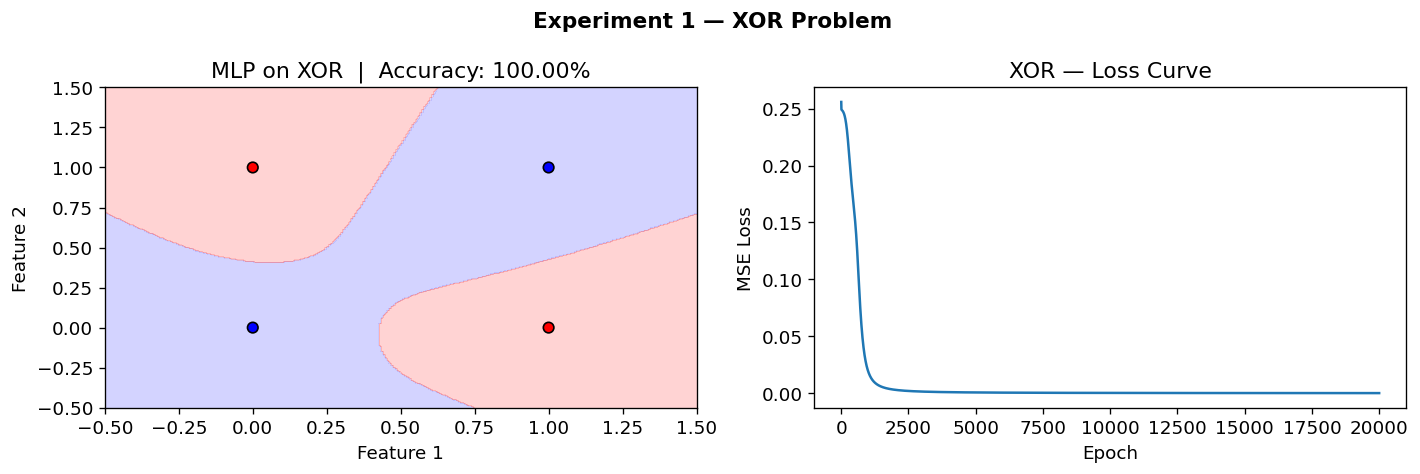

XOR Predictions : [[0 1 1 0]]
XOR Ground Truth: [[0 1 1 0]]
Accuracy        : 100.00%

 EXPERIMENT 2 — Make Moons (Non-Linear Boundary)


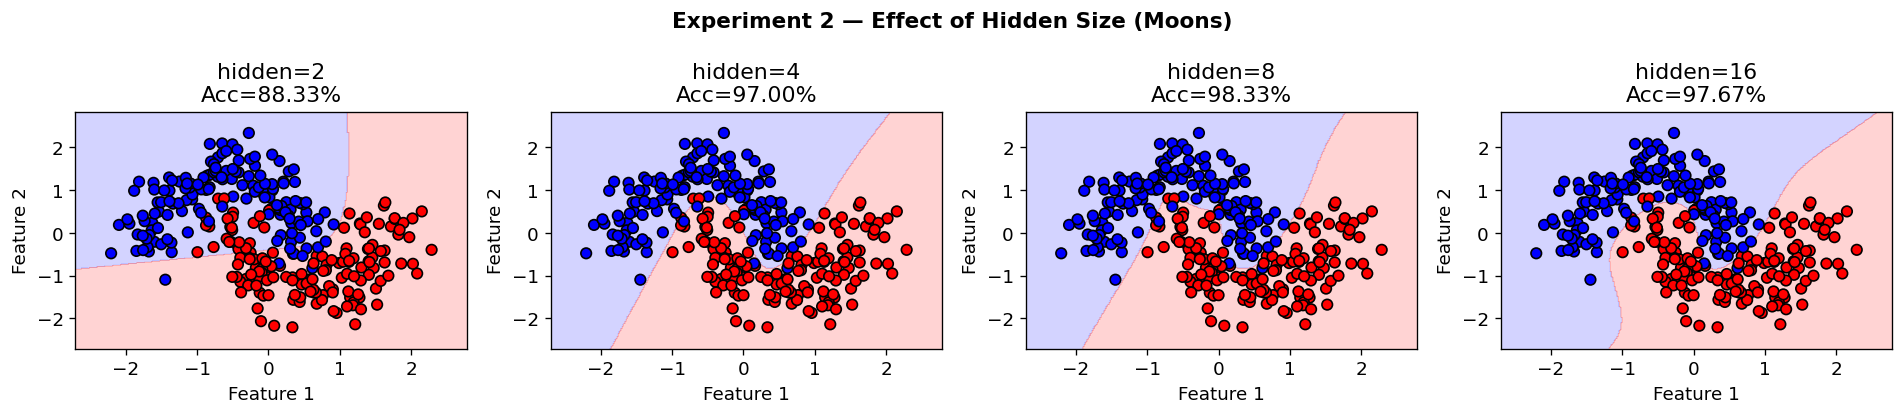

 EXPERIMENT 3 — Loss Convergence


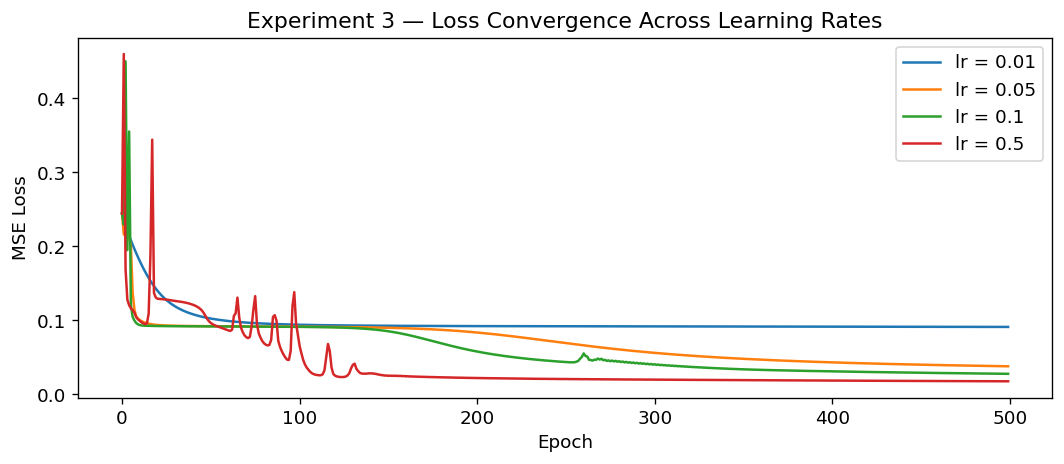

 EXPERIMENT 4 — Breast Cancer Dataset
Test Accuracy : 95.61%

              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



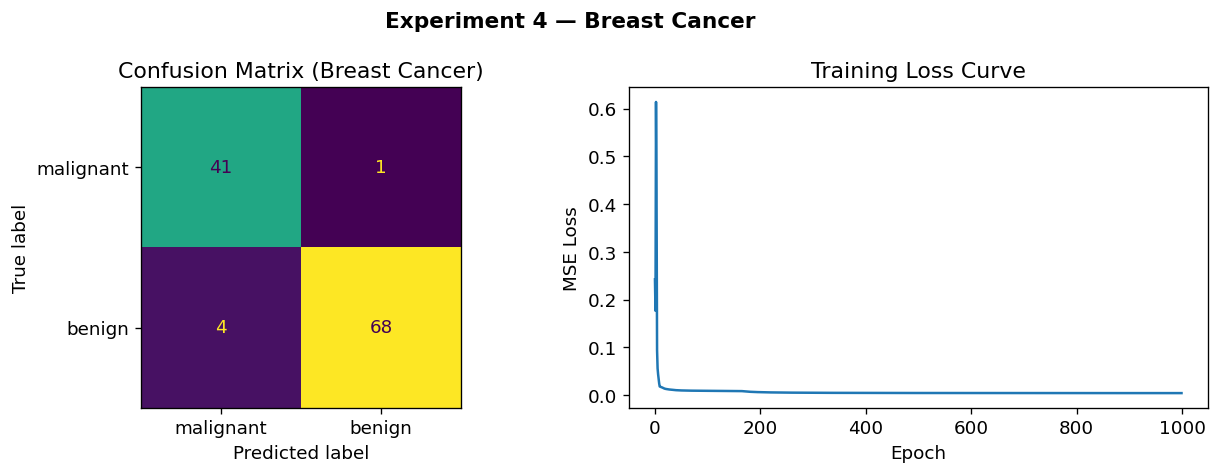

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import sys, os
sys.path.append(os.path.abspath("../../"))
from mlpackage import MultilayerPerceptron

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})


# ── Helper ────────────────────────────────────────────────────────────────────
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2, cmap="bwr")
    ax.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap="bwr", edgecolors="k", s=40)
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")


# ── 1. XOR Problem — MLP vs Perceptron ───────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 1 — XOR: Non-Linear Decision Boundary")
print("=" * 55)

X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([[0],[1],[1],[0]])

model_xor = MultilayerPerceptron(input_size=2, hidden_size=4, output_size=1,
                                  learning_rate=0.5, n_iters=20000)
model_xor.fit(X_xor, y_xor)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_decision_boundary(model_xor, X_xor, y_xor, axes[0],
    f"MLP on XOR  |  Accuracy: {model_xor.score(X_xor, y_xor):.2%}")

ax = axes[1]
ax.plot(model_xor.loss_history)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("XOR — Loss Curve")

plt.suptitle("Experiment 1 — XOR Problem", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"XOR Predictions : {model_xor.predict(X_xor).T}")
print(f"XOR Ground Truth: {y_xor.T}")
print(f"Accuracy        : {model_xor.score(X_xor, y_xor):.2%}\n")


# ── 2. Non-Linear Dataset — Moons ────────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 2 — Make Moons (Non-Linear Boundary)")
print("=" * 55)

X_moon, y_moon = make_moons(n_samples=300, noise=0.2, random_state=42)
y_moon = y_moon.reshape(-1, 1)
X_moon = StandardScaler().fit_transform(X_moon)

hidden_sizes = [2, 4, 8, 16]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, hs in zip(axes, hidden_sizes):
    m = MultilayerPerceptron(input_size=2, hidden_size=hs, output_size=1,
                              learning_rate=0.1, n_iters=3000)
    m.fit(X_moon, y_moon)
    plot_decision_boundary(m, X_moon, y_moon, ax,
        f"hidden={hs}\nAcc={m.score(X_moon, y_moon):.2%}")

plt.suptitle("Experiment 2 — Effect of Hidden Size (Moons)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


# ── 3. Loss Convergence Across Learning Rates ─────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 3 — Loss Convergence")
print("=" * 55)

learning_rates = [0.01, 0.05, 0.1, 0.5]
fig, ax = plt.subplots(figsize=(9, 4))
for lr in learning_rates:
    m = MultilayerPerceptron(input_size=2, hidden_size=8, output_size=1,
                              learning_rate=lr, n_iters=500)
    m.fit(X_moon, y_moon)
    ax.plot(m.loss_history, label=f"lr = {lr}")

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Experiment 3 — Loss Convergence Across Learning Rates")
ax.legend()
plt.tight_layout()
plt.show()


# ── 4. Real Dataset — Breast Cancer ──────────────────────────────────────────
print("=" * 55)
print(" EXPERIMENT 4 — Breast Cancer Dataset")
print("=" * 55)

data = load_breast_cancer()
X_raw, y_raw = data.data, data.target.reshape(-1, 1)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_te_s  = sc.transform(X_te)

clf = MultilayerPerceptron(input_size=30, hidden_size=16, output_size=1,
                            learning_rate=0.1, n_iters=1000)
clf.fit(X_tr_s, y_tr)
y_pred = clf.predict(X_te_s)

print(f"Test Accuracy : {clf.score(X_te_s, y_te):.2%}\n")
print(classification_report(y_te, y_pred, target_names=data.target_names))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred),
                       display_labels=data.target_names).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix (Breast Cancer)")

axes[1].plot(clf.loss_history)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].set_title("Training Loss Curve")

plt.suptitle("Experiment 4 — Breast Cancer", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()